Notebook 4 - Walk Forward Validation

In [1]:
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "data").is_dir() and (ROOT.parent / "data").is_dir():
    ROOT = ROOT.parent
DATA = ROOT / "data"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cvxpy as cp
from hmmlearn.hmm import GaussianHMM
from sklearn.covariance import LedoitWolf
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 5)
np.random.seed(42)

In [3]:
# Dataset with all features (for HMM training)
dataset = pd.read_csv(DATA / 'processed' / 'dataset.csv', index_col=0, parse_dates=True)

# Asset returns for portfolio accounting
simplert = pd.read_csv(DATA / 'processed' / 'simplert.csv', index_col=0, parse_dates=True).dropna()

print(f'Dataset: {dataset.shape}, {dataset.index[0].date()} to {dataset.index[-1].date()}')
print(f'Returns: {simplert.shape}, {simplert.index[0].date()} to {simplert.index[-1].date()}')
print(f'Assets: {simplert.columns.tolist()}')

Dataset: (4760, 9), 2006-02-02 to 2024-12-31
Returns: (5031, 4), 2005-01-05 to 2024-12-31
Assets: ['SPY', 'TLT', 'GLD', 'CASH']


In [4]:
# Redefining optimisers

def minvar(sigma, maxcash=0.80):
    n = sigma.shape[0]
    w = cp.Variable(n)
    problem = cp.Problem( cp.Minimize(cp.quad_form(w, cp.psd_wrap(sigma))), [cp.sum(w) == 1, w >= 0, w[-1] <= maxcash])
    problem.solve()
    if problem.status not in ['optimal', 'optimal_inaccurate']:
        return np.ones(n) / n
    return w.value

def maxsharpe(mu, sigma, maxcash=0.50):
    n = len(mu)
    if np.max(mu) <= 0:
        return minvar(sigma, maxcash)
    y = cp.Variable(n)
    problem = cp.Problem(cp.Minimize(cp.quad_form(y, cp.psd_wrap(sigma))), [mu @ y == 1, y >= 0, y[-1] <= maxcash * cp.sum(y)])
    problem.solve()
    if problem.status not in ['optimal', 'optimal_inaccurate']:
        return minvar(sigma, maxcash)
    return y.value / np.sum(y.value)

In [5]:
def buildfeatures(dataset_slice):
    """Rebuild HMM features from raw dataset."""
    spyvol21d = dataset_slice['SPYlogret'].rolling(21).std() * np.sqrt(252)
    
    features = pd.DataFrame({
        'SPYlogret'  : dataset_slice['SPYlogret'],
        'SPYvol21d'  : spyvol21d,
        'vix'        : dataset_slice['VIX'],
        'yieldspread': dataset_slice['YIELDSPREAD'],
        'unrate'     : dataset_slice['UNRATE'],
    })
    return features.dropna()

In [ ]:
def refitatdate(t, dataset, n=3, randomstate=42):
    """
    Perform one walkforward step: refit HMM using only data up to (and including) t, return regime probabilities at t.
    
    Parameter(s)
    t : pd.Timestamp
        The rebalance date.
    dataset : pd.DataFrame
        Full dataset (will be sliced to t).
    
    Return(s)
    dict with keys:
        'regprobs' : array of [pcrisis, precovery, pbull] at date t
        'trainingfeatures' : DataFrame of features used for training
        'trainingfeaturesz' : standardized version
        'trainingreglabels' : hard regime labels for training period
        'featuremean', 'featurestd' : standardization stats
    """
    # Slice dataset strictly up to t
    traindata = dataset.loc[:t]

    # Build features
    features = buildfeatures(traindata)
    
    # Standardize using training stats only
    featmean = features.mean()
    featstd  = features.std()
    featuresz = (features - featmean) / featstd
    
    # Fit HMM
    X = featuresz.values
    model = GaussianHMM(n_components=n, covariance_type='full', n_iter=500, random_state=randomstate, tol=1e-4)
    model.fit(X)
    
    # Identify regimes by profile matching
    means_df = pd.DataFrame(model.means_, columns=featuresz.columns)
    
    profiles = {
        'crisis': {'SPYlogret': -1, 'SPYvol21d': +1, 'vix': +1, 'unrate': +1},
        'recovery': {'SPYlogret': +1, 'SPYvol21d': -1, 'yieldspread': +1, 'unrate': +1},
        'bullish': {'SPYlogret': +1, 'SPYvol21d': -1, 'vix': -1, 'unrate': -1},
    }
    
    def scorestate(stateidx, profile):
        return sum(
            1 if np.sign(means_df.loc[stateidx, feat]) == sign else -1
            for feat, sign in profile.items()
        )
    
    statescores = {s: {p: scorestate(s, profiles[p]) for p in profiles} 
                    for s in range(n)}
    
    # Assign: highest crisisscore - Crisis, highest recoveryscore (excluding crisis) - Recovery, rest - Bull
    crisisstate = max(statescores, key=lambda s: statescores[s]['crisis'])
    remaining = [s for s in range(n) if s != crisisstate]
    recoverystate = max(remaining, key=lambda s: statescores[s]['recovery'])
    bullstate = [s for s in remaining if s != recoverystate][0]
    
    relabel = {crisisstate: 0, recoverystate: 1, bullstate: 2}
    
    # Get soft regime probabilities for the last observation (date t)
    rawprobs = model.predict_proba(X)
    # Reorder columns by relabel
    relabledprobs = np.zeros_like(rawprobs)
    for old, new in relabel.items():
        relabledprobs[:, new] = rawprobs[:, old]
    
    probst = relabledprobs[-1]  # last row = date t
    
    # Also return hard labels for entire training period
    hardstatesraw = model.predict(X)
    hardstates = np.array([relabel[s] for s in hardstatesraw])
    
    return {
        'regprobs'       : probst,
        'trainingfeatures'  : features,
        'trainingreglabels': pd.Series(hardstates, index=features.index),
        'featuremean'       : featmean,
        'featurestd'        : featstd,
        'relabelmapping'    : relabel,
    }

In [7]:
testdate = pd.Timestamp('2015-06-30')

result = refitatdate(testdate, dataset)

print(f'Refit at date: {testdate.date()}')
print(f'Training features: {result["trainingfeatures"].shape}')
print(f'Regime probabilities at {testdate.date()}:')
print(f'  Crisis:   {result["regprobs"][0]:.3f}')
print(f'  Recovery: {result["regprobs"][1]:.3f}')
print(f'  Bull:     {result["regprobs"][2]:.3f}')
print(f'Sum (should be 1.0): {result["regprobs"].sum():.6f}')
print(f'\nRelabel mapping: {result["relabelmapping"]}')

# Verify no look-ahead
print(f'\nLast training date: {result["trainingfeatures"].index[-1].date()}')
assert result["trainingfeatures"].index[-1] <= testdate, "Lookahead bias detected"
print('No lookahead. Training data ends at or before rebalance date')

Refit at date: 2015-06-30
Training features: (2348, 5)
Regime probabilities at 2015-06-30:
  Crisis:   0.000
  Recovery: 0.641
  Bull:     0.359
Sum (should be 1.0): 1.000000

Relabel mapping: {2: 0, 0: 1, 1: 2}

Last training date: 2015-06-30
No lookahead. Training data ends at or before rebalance date


The (2348, 5) is indicative of the approximately 9.5 years of daily data used for training.

In [8]:
def estimateregparams(refitres, returns):
    """
    Given a refit result (with training regime labels) and asset returns, estimate mu and sigma per regime using only data up to the refit date.
    """
    regimelabels = refitres['trainingreglabels']
    
    commonidx = returns.index.intersection(regimelabels.index)
    rets = returns.loc[commonidx]
    labels = regimelabels.loc[commonidx] 
    
    lwfull = LedoitWolf().fit(rets.values)
    mufull = rets.mean().values * 252
    sigmafull = lwfull.covariance_ * 252
    
    regparams = {}
    for regid in [0, 1, 2]:
        mask = labels == regid
        regimerets = rets[mask] # rets is the returns dataframe, mask is a boolean series that is true for the rows where the regime label is equal to regid
        if len(regimerets) >= 60:
            mu = regimerets.mean().values * 252
            lw = LedoitWolf().fit(regimerets.values)
            sigma = lw.covariance_ * 252
        else:
            mu = mufull
            sigma = sigmafull
        regparams[regid] = {'mu': mu, 'sigma': sigma}
    
    return regparams

In [9]:
def comptargetwts(refitres, returnst):
    """
    Full pipeline at rebalance date, refitres + past returns = blended portfolio weights.
    Regime specific cash constraints:
        Crisis   - Min Variance, max 80% cash (defensive but not paralyzed)
        Recovery - Max Sharpe,   max 40% cash (aggressive risk-on)
        Bull     - Max Sharpe,   max 50% cash (steady deployment)
    """
    regparams = estimateregparams(refitres, returnst)
    
    regimepfs = {}
    regimepfs[0] = minvar(regparams[0]['sigma'], maxcash=0.80)
    regimepfs[1] = maxsharpe(regparams[1]['mu'], regparams[1]['sigma'], maxcash=0.40)
    regimepfs[2] = maxsharpe(regparams[2]['mu'], regparams[2]['sigma'], maxcash=0.50)
    
    probs = refitres['regprobs']
    w = (probs[0] * regimepfs[0] + probs[1] * regimepfs[1] + probs[2] * regimepfs[2])
    
    w = w / w.sum()
    return w, regimepfs, regparams

In [10]:
# Rebalance on the last business day of each month
startdate = pd.Timestamp('2009-02-01')  # about 3 years burnin for HMM
enddate   = simplert.index[-1]

rebalancedts = pd.date_range(start=startdate, end=enddate, freq='BME')

# Align to actual trading days in simplert
rebalancedts = pd.DatetimeIndex([simplert.index[simplert.index.get_indexer([d], method='ffill')[0]] for d in rebalancedts])
rebalancedts = rebalancedts.unique()

print(f'Number of rebalance dates: {len(rebalancedts)}')
print(f'First: {rebalancedts[0].date()}')
print(f'Last:  {rebalancedts[-1].date()}')

Number of rebalance dates: 191
First: 2009-02-27
Last:  2024-12-31


The 191 rebalance dates are indicative of the approximately 16 years of rebalancing.

In [11]:
import time

assets = simplert.columns.tolist()
nassets = len(assets)

targetwtshist = {} # date - target weights
regimeprobshist   = {} # date - [pcrisis, precovery, pbull]
regimepfslog  = {} # date - {regid: weights}

starttime = time.time()

for i, t in enumerate(rebalancedts):
    try:
        # Refit HMM up to t
        refitres = refitatdate(t, dataset)
        # Get past returns (strictly before or on t)
        pastreturns = simplert.loc[:t]
        # Compute target weights
        wtarget, regimepfs, regparams = comptargetwts(refitres, pastreturns)
        # Store
        targetwtshist[t] = wtarget
        regimeprobshist[t]   = refitres['regprobs']
        regimepfslog[t]  = regimepfs
        
        if (i + 1) % 20 == 0:
            elapsed = time.time() - starttime
            pct = (i + 1) / len(rebalancedts) * 100
            print(f'  [{i+1}/{len(rebalancedts)}] {t.date()} 'f'({pct:.0f}%, {elapsed:.1f}s elapsed)')
    
    except Exception as e:
        print(f'ERROR : {t.date()}: {e}')
        # Reuse previous weights if refit fails
        if i > 0:
            prevt = rebalancedts[i-1]
            targetwtshist[t] = targetwtshist[prevt]
            regimeprobshist[t]   = regimeprobshist[prevt]

totaltime = time.time() - starttime
print(f'\nBacktest complete: {totaltime:.1f}s ({totaltime/len(rebalancedts):.2f}s per rebalance)')
print(f'Successful refits: {len(targetwtshist)}/{len(rebalancedts)}')

Model is not converging.  Current: -621.9386336776031 is not greater than -621.9386293888455. Delta is -4.2887576228167745e-06
Model is not converging.  Current: -1496.0556049867887 is not greater than -1496.0555781352957. Delta is -2.6851492975765723e-05


  [20/191] 2010-09-30 (10%, 1.4s elapsed)
  [40/191] 2012-05-31 (21%, 2.9s elapsed)
  [60/191] 2014-01-31 (31%, 4.8s elapsed)
  [80/191] 2015-09-30 (42%, 6.9s elapsed)
  [100/191] 2017-05-31 (52%, 9.1s elapsed)
  [120/191] 2019-01-31 (63%, 11.4s elapsed)
  [140/191] 2020-09-30 (73%, 14.6s elapsed)
  [160/191] 2022-05-31 (84%, 18.5s elapsed)
  [180/191] 2024-01-31 (94%, 23.1s elapsed)

Backtest complete: 25.9s (0.14s per rebalance)
Successful refits: 191/191


In [12]:
targetwtsdf = pd.DataFrame.from_dict(targetwtshist, orient='index', columns=assets).sort_index()

regimeprobsdf = pd.DataFrame.from_dict(regimeprobshist, orient='index', columns=['pcrisis', 'precovery', 'pbull']).sort_index()

print('Target weights summary:')
print(targetwtsdf.describe().round(3))
print()
print('Regime probabilities summary:')
print(regimeprobsdf.describe().round(3))

Target weights summary:
           SPY      TLT      GLD     CASH
count  191.000  191.000  191.000  191.000
mean     0.249    0.197    0.086    0.468
std      0.166    0.091    0.111    0.225
min      0.000   -0.000   -0.000    0.023
25%      0.130    0.116    0.029    0.400
50%      0.221    0.214    0.040    0.500
75%      0.371    0.266    0.091    0.500
max      0.741    0.519    0.669    0.800

Regime probabilities summary:
       pcrisis  precovery    pbull
count  191.000    191.000  191.000
mean     0.203      0.321    0.476
std      0.399      0.465    0.495
min      0.000      0.000    0.000
25%      0.000      0.000    0.000
50%      0.000      0.000    0.005
75%      0.000      1.000    1.000
max      1.000      1.000    1.000


In [13]:
def simulatestrategy(targetwtsdf, simplerets):
    """
    Given target weights at rebalance dates and daily simple returns, simulate the daily portfolio, rebalance on rebalance dates, let weights drift between rebalances.
    
    Return(s)
    actualwts : DataFrame, weights at end of each day
    dailyrets  : Series, daily portfolio return (gross of costs)
    """
    assets = simplerets.columns.tolist()
    n = len(assets)
    
    # Restrict to the backtest period
    start = targetwtsdf.index[0]
    simrets = simplerets.loc[start:]
    
    # Initialize: hold first target weights on day 1
    currentwts = targetwtsdf.iloc[0].values.copy()
    
    actualwts = np.zeros((len(simrets), n))
    dailyrets = np.zeros(len(simrets))
    
    for i, date in enumerate(simrets.index):
        # If today is a rebalance day, set weights to target
        if date in targetwtsdf.index:
            currentwts = targetwtsdf.loc[date].values.copy()
        
        # Daily return, weighted average of asset returns
        dayrets = simrets.iloc[i].values
        dailyrets[i] = currentwts @ dayrets
        
        # Drift weights, each asset's weight grows by its return
        newvals = currentwts * (1 + dayrets)
        currentwts = newvals / newvals.sum()  # renormalize
        
        actualwts[i] = currentwts
    
    actualwtsdf = pd.DataFrame(actualwts, index=simrets.index, columns=assets)
    dailyretseries = pd.Series(dailyrets, index=simrets.index, name='strategy')
    
    return actualwtsdf, dailyretseries

actualwts, grossrets = simulatestrategy(targetwtsdf, simplert)
print('Strategy daily returns:')
print(grossrets.describe())

Strategy daily returns:
count    3988.000000
mean        0.000198
std         0.003651
min        -0.029510
25%        -0.001284
50%         0.000303
75%         0.001870
max         0.021432
Name: strategy, dtype: float64


In [14]:
def applycosts(dailyrets, actualwts, targetwtsdf, bps=10):
    """
    Subtract transaction costs from daily returns.
    Cost = bps × |target - actual| summed across assets, charged on rebalance day.
    """
    costrate = bps / 10000  # bps to decimal
    
    netrets = dailyrets.copy()
    
    for rebaldate in targetwtsdf.index:
        if rebaldate not in actualwts.index:
            continue
        targetw = targetwtsdf.loc[rebaldate].values
        idx = actualwts.index.get_loc(rebaldate)
        if idx == 0:
            continue
        prevw = actualwts.iloc[idx - 1].values
        turnover = np.abs(targetw - prevw).sum()
        cost = turnover * costrate
        netrets.loc[rebaldate] -= cost
    
    return netrets

# Run with 10 bps default
netrets = applycosts(grossrets, actualwts, targetwtsdf, bps=10)

# Comparison
totalgross = (1 + grossrets).prod() - 1
totalnet   = (1 + netrets).prod() - 1
print(f'Gross total return : {totalgross*100:.1f}%')
print(f'Net total return   : {totalnet*100:.1f}%')
print(f'Cost drag          : {(totalgross - totalnet)*100:.1f}%')

Gross total return : 114.3%
Net total return   : 100.5%
Cost drag          : 13.8%


In [15]:
def buildbmark(targetwts, simplerets, name, bps=10):
    """Build a benchmark with monthly rebalancing."""
    n = simplerets.shape[1]
    targetdf = pd.DataFrame(
        np.tile(targetwts, (len(targetwtsdf.index), 1)),
        index=targetwtsdf.index,
        columns=simplerets.columns
    )
    actual, gross = simulatestrategy(targetdf, simplerets)
    net = applycosts(gross, actual, targetdf, bps=bps)
    return net.rename(name)

# 60/40 benchmark: 60% SPY, 40% TLT, 0% GLD, 0% CASH
bmark6040 = buildbmark(np.array([0.6, 0.4, 0.0, 0.0]), simplert, '60_40', bps=10)

# Equal weight benchmark
bmarkeqw = buildbmark(np.array([0.25, 0.25, 0.25, 0.25]), simplert, 'EqualWeight', bps=10)

print(f'60/40 total return        : {((1+bmark6040).prod() - 1)*100:.1f}%')
print(f'Equal weight total return : {((1+bmarkeqw).prod() - 1)*100:.1f}%')
print(f'Strategy total return     : {((1+netrets).prod() - 1)*100:.1f}%')

60/40 total return        : 399.8%
Equal weight total return : 180.7%
Strategy total return     : 100.5%


In [16]:
def perfmetrics(returns, name='Strategy'):
    nyears = len(returns) / 252
    totalret = (1 + returns).prod() - 1
    annret   = (1 + totalret) ** (1 / nyears) - 1
    annvol   = returns.std() * np.sqrt(252)
    sharpe   = annret / annvol if annvol > 0 else 0
    
    downside = returns[returns < 0]
    downsidevol = downside.std() * np.sqrt(252) if len(downside) > 0 else 0
    sortino = annret / downsidevol if downsidevol > 0 else 0
    
    equity = (1 + returns).cumprod()
    maxdd = ((equity - equity.cummax()) / equity.cummax()).min()
    calmar = annret / abs(maxdd) if maxdd < 0 else 0
    
    return {
        'name'         : name,
        'annualreturn%': round(annret * 100, 2),
        'annualvol%'   : round(annvol * 100, 2),
        'sharpe'       : round(sharpe, 2),
        'sortino'      : round(sortino, 2), # Sortino is the ratio of the annualized return to the downside deviation
        'maxdd%'       : round(maxdd * 100, 2), # Maximum drawdown is the maximum loss from a peak to a trough of a portfolio, often expressed as a percentage of the peak
        'calmar'       : round(calmar, 2), # Calmar is the ratio of the annualized return to the maximum drawdown
    }

metrics = pd.DataFrame([
    perfmetrics(netrets, 'Strategy'),
    perfmetrics(bmark6040, '60/40'),
    perfmetrics(bmarkeqw, 'EqualWeight'),
]).set_index('name')

print(metrics.to_string())

             annualreturn%  annualvol%  sharpe  sortino  maxdd%  calmar
name                                                                   
Strategy              4.49        5.80    0.77     0.90  -11.42    0.39
60/40                10.70       10.20    1.05     1.38  -27.71    0.39
EqualWeight           6.74        6.86    0.98     1.37  -17.60    0.38


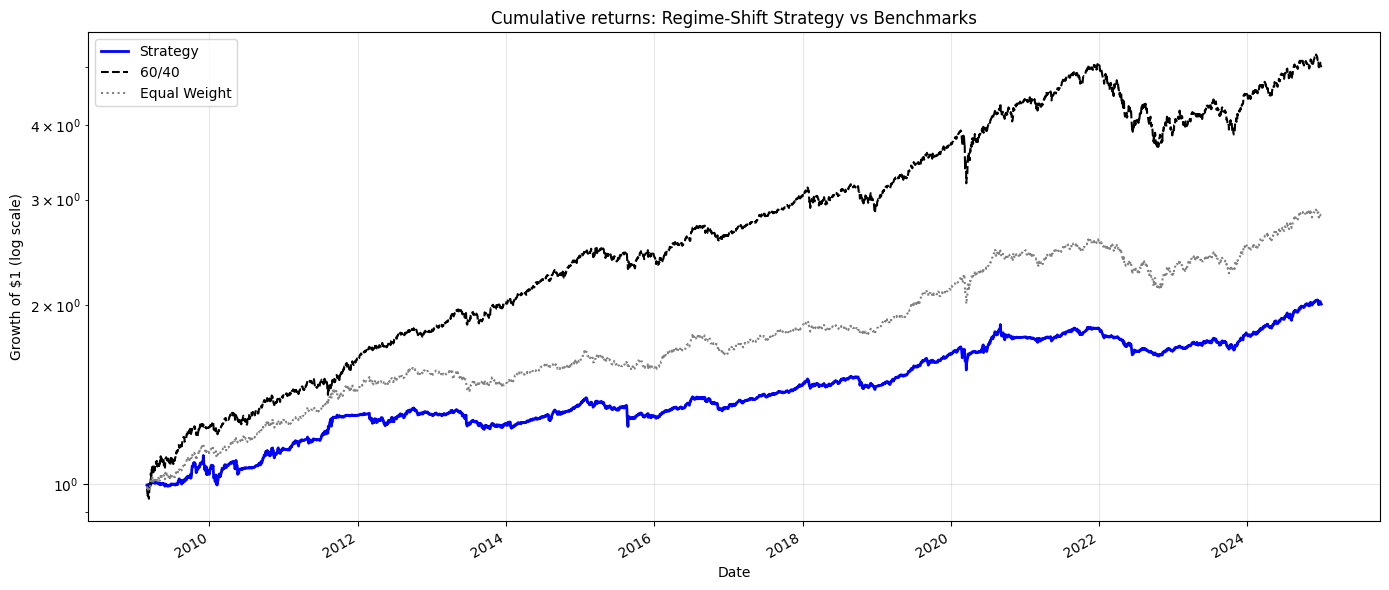

In [17]:
fig, axes = plt.subplots(figsize=(14, 6))
(1 + netrets).cumprod().plot(ax=axes, label='Strategy', linewidth=2, color='blue')
(1 + bmark6040).cumprod().plot(ax=axes, label='60/40', linewidth=1.5, color='black', linestyle='--')
(1 + bmarkeqw).cumprod().plot(ax=axes, label='Equal Weight', linewidth=1.5, color='gray', linestyle=':')
axes.set_title('Cumulative returns: Regime-Shift Strategy vs Benchmarks')
axes.set_ylabel('Growth of $1 (log scale)')
axes.set_yscale('log')
axes.legend(loc='upper left')
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

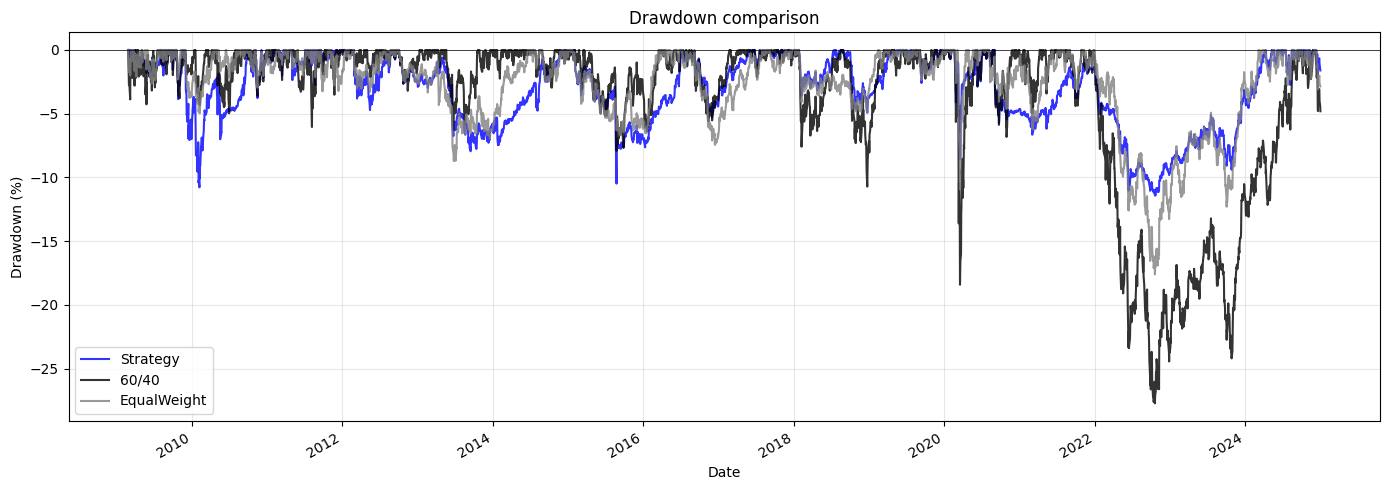

In [18]:
fig, axes = plt.subplots(figsize=(14, 5))
for label, ret, color in [
    ('Strategy', netrets, 'blue'),
    ('60/40', bmark6040, 'black'),
    ('EqualWeight', bmarkeqw, 'gray')
]:
    equity = (1 + ret).cumprod()
    dd = (equity - equity.cummax()) / equity.cummax() * 100
    dd.plot(ax=axes, label=label, color=color, alpha=0.8)
axes.axhline(0, color='black', linewidth=0.5)
axes.set_title('Drawdown comparison')
axes.set_ylabel('Drawdown (%)')
axes.legend(loc='lower left')
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

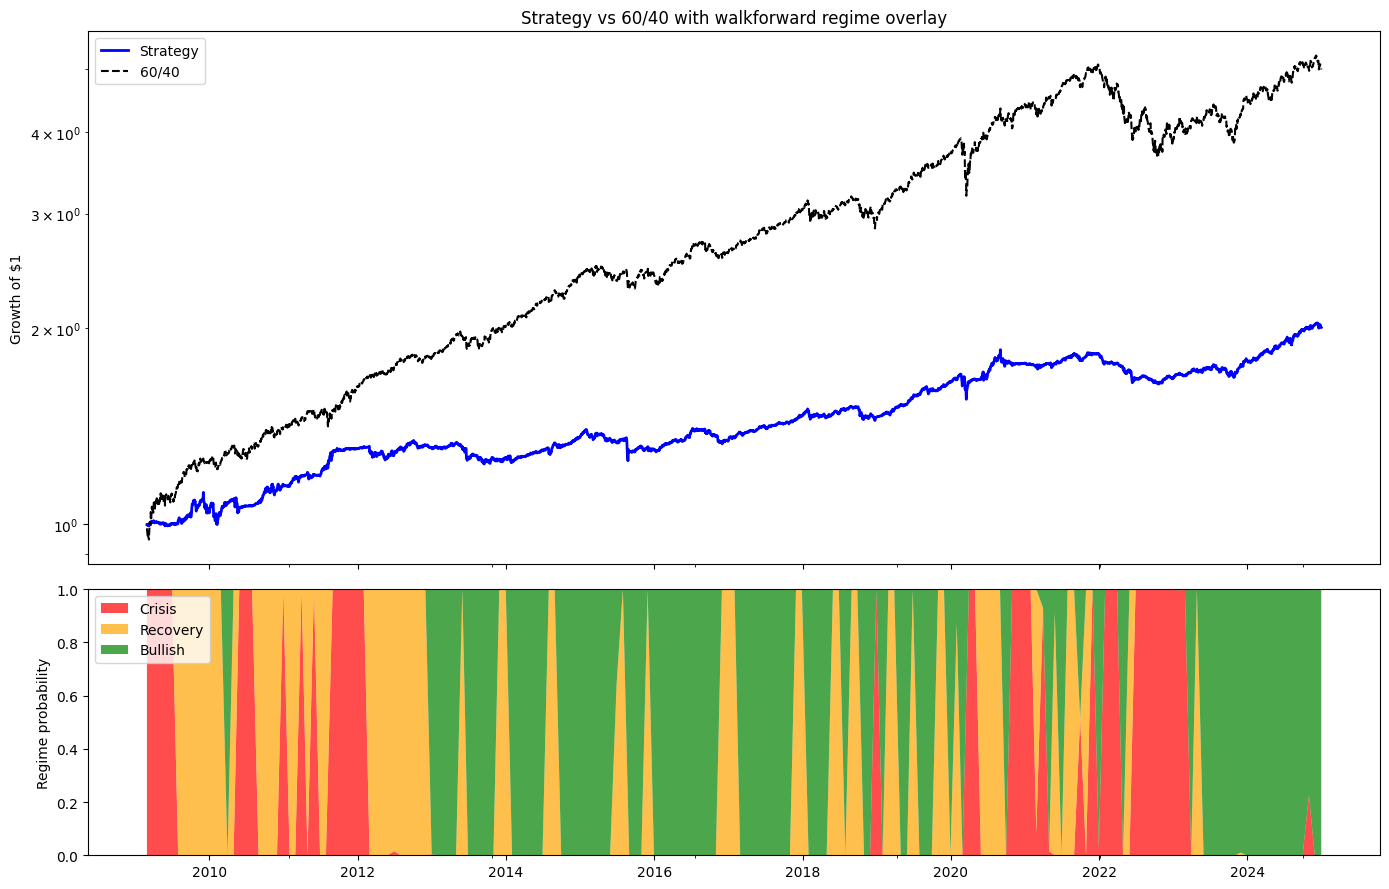

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

(1 + netrets).cumprod().plot(ax=axes[0], label='Strategy', linewidth=2, color='blue')
(1 + bmark6040).cumprod().plot(ax=axes[0], label='60/40', linewidth=1.5, color='black', linestyle='--')
axes[0].set_yscale('log')
axes[0].set_ylabel('Growth of $1')
axes[0].legend(loc='upper left')
axes[0].set_title('Strategy vs 60/40 with walkforward regime overlay')

axes[1].stackplot(
    regimeprobsdf.index,
    regimeprobsdf['pcrisis'],
    regimeprobsdf['precovery'],
    regimeprobsdf['pbull'],
    labels=['Crisis', 'Recovery', 'Bullish'],
    colors=['red', 'orange', 'green'],
    alpha=0.7,
)
axes[1].set_ylabel('Regime probability')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper left')
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [20]:
resultsdir = DATA / 'processed' / 'backtest'
resultsdir.mkdir(exist_ok=True)

targetwtsdf.to_csv(resultsdir / 'targetweights.csv')
actualwts.to_csv(resultsdir / 'actualweights.csv')
regimeprobsdf.to_csv(resultsdir / 'regimeprobswf.csv')
netrets.to_csv(resultsdir / 'strategyreturns.csv')
bmark6040.to_csv(resultsdir / 'benchmark6040.csv')
bmarkeqw.to_csv(resultsdir / 'benchmarkeqw.csv')
metrics.to_csv(resultsdir / 'performancemetrics.csv')